<a href="https://colab.research.google.com/github/zydanne-costa/Ondas_ADCP_SCO_Mar_Nov_2025/blob/main/main_strk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

O objetivo principal dessa rotina é extrair altura e período de onda dos arquivos de surfacetrack.

Após o cálculos os df são salvos no diretório '/content/drive/MyDrive/Ondas/Dados/Refinados/'

# 1.IMPORTAÇÃO DE BIBLIOTECAS

In [ ]:
import pandas as pd # manipulacao de tempo e dataframes
import numpy as np # calculos
import os # caminhos de diretorios
from glob import glob #trabalhar com arquivos/ listas
import matplotlib.pyplot as plt # graficos
import matplotlib.ticker as mticker
import matplotlib.dates as mdates

Esta célula de código importa todas as bibliotecas Python necessárias para manipulação de dados, cálculos numéricos, operações de sistema de arquivos, plotagem e formatação de datas.

# 2.ACESSO AO DRIVE

In [ ]:
from google.colab import drive # import do modulo drive de google.colab
drive.mount('/content/drive')

Mounted at /content/drive


# 3.FUNÇÕES AUXILIARES

## WINDOW

Função para janela de suavização

In [ ]:
def window(N, wt):

    nn = N - 1
    pn = 2 * np.pi * np.arange(0, nn + 1) / nn

    if wt[:4] == 'rect': w = np.ones(N)

    elif wt[:4] == 'blac': # blackman Window (filtro)
        w = (0.42- 0.5 * np.cos(pn)+ 0.08 * np.cos(2 * pn))

    else:
        raise ValueError('Tipo de janela inválido')

    return w # w = vetor de pesos

    # redução dos ruídos, efeitos de borda e suavização

Esta função `window(N, wt)` gera um array de janela (pesos) para processamento de sinal. Ela suporta uma janela retangular (`'rect'`) ou uma janela Blackman (`'blac'`). A janela Blackman é tipicamente usada para redução de ruído, efeitos de borda e suavização na análise de sinais.

##WEIM
Aplicar média movel ponderada após percorrer a série de dados (x) utilizando a janela Blackman.

Estimo que a maré tem uma tendencia lenta, com isso consigo 'capturar' o sinal da maré

In [ ]:
def weim(N, wt, x):

    w = window(N, wt)

    x = np.array(x).flatten()

    ln = (N - 1) // 2
    lx = len(x)
    lf = lx - ln

    y = np.zeros_like(x)

    for i in range(lx):

        # início
        if i < ln:

            y[i] = (
                np.sum(x[:ln+i+1] * w[ln-i:])
                / np.sum(w[ln-i:])
            )

        # centro
        elif i >= ln and i < lf:

            y[i] = (
                np.sum(x[i-ln:i+ln+1] * w)
                / np.sum(w)
            )

        # final
        else:

            y[i] = (np.sum(x[i-ln:] * w[:len(x[i-ln:])])/ np.sum(w[:len(x[i-ln:])]))

    return y

A função `weim(N, wt, x)` aplica uma média móvel ponderada à série de entrada `x` usando uma janela gerada pela função `window`. Ela lida com casos de borda para o início e o fim da série, suavizando efetivamente os dados para extrair um sinal de 'maré' dos dados amostrados.

# 4.FUNÇÕES DE PROCESSAMENTO

## processar_strk

Aqui eu leio o txt bruto, concateno em um df com tempo e altura de onda

In [ ]:
#STRK

def processar_strk(
    caminho_pasta,
    nome_saida
):
    # leitura dos arquivos .txt
    arquivos = sorted(
        glob(
            os.path.join(
                caminho_pasta,
                '*.txt'
            )
        )
    )

    lista_df = []

    for arq in arquivos:

        nome_arquivo = os.path.basename(arq)

        # =================================================
        # DATA
        # =================================================

        data_str = (
            nome_arquivo # extraio a data a partir do nome com AA/MM/DD/HH:MM:ss:mm
            .replace('STrk', '')
            .replace('.txt', '')
        )

        data_inicial = pd.to_datetime(
            data_str,
            format='%Y%m%d%H%M%S%f' # isso define o inicio do arquivo
        )

        # =================================================
        # LEITURA
        # =================================================

        dados = np.loadtxt(
            arq,
            comments='%'
        ) # lendo os arquivos e separando por coluna

        # garantir matriz Nx4
        if dados.ndim == 1:

            continue

        # =================================================
        # INVÁLIDOS
        # =================================================

        dados[dados == 0] = np.nan

        dados[dados == -32768] = np.nan

        # =================================================
        # mm -> m
        # =================================================

        dados = dados / 1000

        # =================================================
        # DATAFRAME
        # =================================================

        dados = pd.DataFrame(
            dados,
            columns=[
                'B1_m',
                'B2_m',
                'B3_m',
                'B4_m'
            ]
        )

        # =================================================
        # INTERPOLAÇÃO
        # apenas gaps pequenos
        # =================================================

        for col in [
            'B1_m',
            'B2_m',
            'B3_m',
            'B4_m'
        ]:

            dados[col] = (
                dados[col]
                .interpolate(
                    limit=4 # interpola até 2 segundos de falha
                )
            )

        # =================================================
        # REMOVER MARÉ
        # =================================================

        dados['B1_h'] = ( # n amostral
            dados['B1_m']
            - weim( # sinal de maré sendo subtraidos do n amostral
                275,
                'blac',
                dados['B1_m'] # o resultado é o sinal de ondas (n_wave = n_amostral - n_maré)
            )
        )

        dados['B2_h'] = (
            dados['B2_m']
            - weim(
                275,
                'blac',
                dados['B2_m']
            )
        )

        dados['B3_h'] = (
            dados['B3_m']
            - weim(
                275,
                'blac',
                dados['B3_m']
            )
        )

        dados['B4_h'] = (
            dados['B4_m']
            - weim(
                275,
                'blac',
                dados['B4_m']
            )
        )

        # =================================================
        # TEMPO ORIGINAL
        # 2 Hz = 0.5 s
        # =================================================

        tempo = pd.date_range(
            start=data_inicial,
            periods=len(dados),
            freq='500ms'
        )

        dados['DataHora'] = tempo

        # =================================================
        # DATAFRAME FINAL
        # =================================================

        dados_final = dados[
            [
                'DataHora',
                'B1_h',
                'B2_h',
                'B3_h',
                'B4_h'
            ]
        ]

        lista_df.append(
            dados_final
        )

    # =====================================================
    # CONCATENAR
    # =====================================================

    if len(lista_df) == 0:
      raise ValueError('Nenhum arquivo encontrado')

    df_final = pd.concat(
        lista_df,
        ignore_index=True
    )

    # ordenar
    df_final = df_final.sort_values(
        'DataHora'
    )

    # reset índice
    df_final = df_final.reset_index(
        drop=True
    )

    # =====================================================
    # CORTES TEMPORAIS
    # =====================================================

    if nome_saida == 'Strk_CHU': # chuvoso

        inicio = pd.to_datetime(
            '2025-03-27 13:20:00'
        )

        fim = pd.to_datetime(
            '2025-04-02 16:00:00' # 6 dias 2 h e 40 min / 146,66 horas
        )

        df_final = df_final[
            (
                df_final['DataHora']
                >= inicio
            )
            &
            (
                df_final['DataHora']
                <= fim
            )
        ]

    if nome_saida == 'Strk_SEC':

        inicio = pd.to_datetime(
            '2025-11-22 18:00:00'
        )

        fim = pd.to_datetime(
            '2025-11-30 09:00:00' # 7 dias e 15 horas
        )

        df_final = df_final[
            (
                df_final['DataHora']
                >= inicio
            )
            &
            (
                df_final['DataHora']
                <= fim
            )
        ]

        # =================================================
        # PADRONIZAR DURAÇÃO TEMPORAL
        # =================================================

        duracao_chu = (

            pd.to_datetime(
                '2025-04-02 16:00:00'
            )

            -

            pd.to_datetime(
                '2025-03-27 13:20:00'
            )

        )

        novo_fim = (
            inicio
            + duracao_chu
        )

        df_final = df_final[
            df_final['DataHora']
            <= novo_fim
        ]

    # =====================================================
    # RESET ÍNDICE
    # =====================================================

    df_final = df_final.reset_index(
        drop=True
    )

    # =====================================================
    # SALVAR CSV
    # =====================================================

    caminho_saida = (
        '/content/drive/MyDrive/'
        'Ondas/Dados/Refinados/'
        f'{nome_saida}.csv'
    )

    df_final.to_csv(
        caminho_saida,
        index=False,
        date_format='%Y-%m-%d %H:%M:%S.%f'
    )

    return df_final

A função `processar_strk` foi projetada para ler e processar arquivos surfacetrack `.txt`. Ela executa as seguintes etapas:
1.  **Leitura de Arquivos**: Lê todos os arquivos `.txt` de um diretório especifico.
2.  **Extração de Data**: Extrai a data e hora de início do nome do arquivo.
3.  **Carregamento de Dados**: Carrega dados numéricos dos arquivos `.txt`.
4.  **Tratamento de Dados Inválidos**: Substitui os valores `0` e `-32768` por `NaN` (Não é um Número).
5.  **Conversão de Unidades**: Converte os dados de milímetros para metros.
6.  **Criação de DataFrame**: Organiza os dados em um DataFrame Pandas com as colunas 'B1_m', 'B2_m', 'B3_m', 'B4_m'.
7.  **Interpolação**: Preenche pequenas lacunas (até 2 segundos) nos dados usando interpolação linear.
8.  **Remoção de Maré**: Aplica a função `weim` (com uma janela Blackman) para remover o sinal de maré de cada feixe, resultando em dados de altura de onda ('B1_h', 'B2_h', 'B3_h', 'B4_h').
9.  **Criação de Série Temporal**: Cria uma coluna `DataHora` (DateTime) com base na hora de início extraída e uma frequência de amostragem de 2 Hz (0.5s).
10. **Concatenação de DataFrames**: Combina todos os dataframes processados em um único DataFrame.
11. **Recorte Temporal**: Filtra o DataFrame com base em intervalos de data específicos ('Chuvoso' e 'Seco') e padroniza a duração.
12. **Exportação para CSV**: Salva o DataFrame final processado em um arquivo CSV no diretório 'Refinados' especificado.

# 5.FUNÇÃO DE ONDAS

Utilizando zero-upcrossing, cruzamento ascendente do nível zero

## individual_waves

In [ ]:
# =========================================================
# ONDAS INDIVIDUAIS
# MÉTODO ZERO-UPCROSSING
# =========================================================

def individual_waves(
    serie,
    tempo,
):

    # =====================================================
    # ARRAY
    # =====================================================

    serie = np.array(serie)

    tempo = pd.Series(
        pd.to_datetime(tempo)
    ).reset_index(drop=True)

    # =====================================================
    # REMOVER NaN
    # =====================================================

    mascara = ~np.isnan(serie)

    serie = serie[mascara]

    tempo = tempo[mascara]

    # =====================================================
    # REMOVER NÍVEL MÉDIO
    # =====================================================

    serie = serie - np.mean(serie)

    # =====================================================
    # CRUZAMENTOS ASCENDENTES
    # =====================================================

    cruzasc = np.where(

        (serie[:-1] < 0)

        &

        (serie[1:] >= 0)

    )[0]

    # =====================================================
    # LISTAS
    # =====================================================

    alturas = []

    periodos = []

    tempo_ondas = []

    # =====================================================
    # LOOP DAS ONDAS
    # =====================================================

    for i in range(len(cruzasc)-1):

        ini = cruzasc[i]

        fim = cruzasc[i+1]

        trecho = serie[
            ini:fim
        ]

        if len(trecho) > 0:

            # =============================================
            # ALTURA
            # =============================================

            H = (
                np.max(trecho)
                -
                np.min(trecho)
            )

            # =============================================
            # PERÍODO
            # =============================================

            T = (
                tempo.iloc[fim]
                -
                tempo.iloc[ini]
            ).total_seconds()

            # filtro fisico para tempo
            # filtro físico
            if T > 30:
                continue

            # =============================================
            # TEMPO CENTRAL DA ONDA
            # =============================================

            tempo_central = (
                tempo.iloc[ini]
                +
                (
                    tempo.iloc[fim]
                    -
                    tempo.iloc[ini]
                ) / 2
            )

            alturas.append(H)

            periodos.append(T)

            tempo_ondas.append(
                tempo_central
            )

    # =====================================================
    # DATAFRAME FINAL
    # =====================================================

    df_ondas = pd.DataFrame({

        'DataHora': tempo_ondas,

        'H': alturas,

        'T': periodos

    })

    return df_ondas

A função `individual_waves(serie, tempo)` identifica ondas individuais e calcula sua altura (H) e período (T) usando o método de cruzamento de zero ascendente. Ela executa as seguintes etapas:
1.  **Preparação dos Dados**: Converte a série de entrada e o tempo para arrays NumPy e Series Pandas, respectivamente.
2.  **Remoção de NaN**: Remove valores ausentes (`NaN`) da série e dos pontos de tempo correspondentes.
3.  **Remoção do Nível Médio**: Subtrai a média da série para centralizá-la em torno de zero.
4.  **Detecção de Cruzamento de Zero Ascendente**: Identifica os pontos onde a série cruza zero de negativo para positivo.
5.  **Cálculo dos Parâmetros da Onda**: Para cada onda identificada (entre dois cruzamentos de zero ascendentes consecutivos):
    *   **Altura (H)**: Calculada como a diferença entre os valores máximo e mínimo dentro do segmento da onda.
    *   **Período (T)**: Calculado como a diferença de tempo entre os dois cruzamentos de zero ascendentes. Um filtro físico é aplicado para excluir períodos maiores que 30 segundos.
    *   **Tempo Central**: Determina o ponto de tempo central de cada onda.
6.  **Saída do DataFrame**: Retorna um DataFrame contendo `DataHora` (tempo central), `H` (altura) e `T` (período) para cada onda individual.

## H_T

In [ ]:
# =========================================================
# EXTRAIR H E T DE TODOS OS BEAMS
# =========================================================

def processar_ondas_individuais(df):

    resultados = []

    beams = [
        'B1_h',
        'B2_h',
        'B3_h',
        'B4_h'
    ]

    for beam in beams:

        print(f'Processando {beam}...')

        df_ondas = individual_waves(

            serie=df[beam],

            tempo=df['DataHora']

        )

        df_ondas = df_ondas.rename(
            columns={

                'H': f'{beam[:2]}_H',

                'T': f'{beam[:2]}_T'

            }
        )

        resultados.append(df_ondas)

    # =====================================================
    # CONCATENAR
    # =====================================================

    df_final = pd.concat(
        resultados,
        axis=1
    )

    # remover colunas repetidas DataHora
    df_final = df_final.loc[
        :,
        ~df_final.columns.duplicated()
    ]

    return df_final

A função `processar_ondas_individuais(df)` aplica a função `individual_waves` a cada um dos quatro feixes (`B1_h`, `B2_h`, `B3_h`, `B4_h`) no DataFrame de entrada. Em seguida, concatena os resultados, renomeando as colunas de altura e período para incluir o identificador do feixe (por exemplo, `B1_H`, `B1_T`). Finalmente, remove as colunas `DataHora` duplicadas resultantes da concatenação, fornecendo um único DataFrame com parâmetros de onda individuais para todos os feixes.

## calc_hs_beams
encontro ondas individuais em cada beam, junto todas, coloco em ordem decrescente, pego 1/3 das maiores e faço a média.

In [ ]:
def calc_hs_beams(df):

    alturas_total = []

    beams = [
        'B1_h',
        'B2_h',
        'B3_h',
        'B4_h'
    ]

    for beam in beams:

        df_ondas = individual_waves(
            serie=df[beam],
            tempo=df['DataHora']
        )

        alturas_total.extend(
            df_ondas['H'].values
        )

    alturas_total = np.array(
        alturas_total
    )

    if len(alturas_total) == 0:

        return np.nan

    # ordenar decrescente
    alturas_total = np.sort(
        alturas_total
    )[::-1]

    # 1/3 maiores
    n = int(
        len(alturas_total) / 3
    )

    if n == 0:

        return np.nan

    hs = np.mean(
        alturas_total[:n]
    )

    return hs

A função `calc_hs_beams(df)` calcula a **altura significativa da onda (Hs)** para todos os feixes combinados. Ela funciona da seguinte forma:
1.  **Alturas de Ondas Individuais**: Itera por cada feixe ('B1_h' a 'B4_h') e usa `individual_waves` para extrair as alturas de ondas individuais (`H`) para cada feixe.
2.  **Alturas Agregadas**: Todas as alturas de ondas individuais de todos os feixes são coletadas em um único array `alturas_total`.
3.  **Ordenar e Selecionar**: O array `alturas_total` é ordenado em ordem decrescente, e o terço superior das maiores alturas de ondas é selecionado.
4.  **Calcular Hs**: A altura significativa da onda (Hs) é calculada como a média dessas alturas de ondas do terço superior. Se nenhuma onda for encontrada, ela retorna `np.nan`.

## calc_hs_intervalado

In [ ]:
# =========================================================
# Hs INTERVALADO
# =========================================================

def calc_hs_intervalo(df, intervalo):

    resultados = []

    grupos = df.resample(
        intervalo,
        on='DataHora'
    )

    for tempo, grupo in grupos:

        alturas_total = []

        # =============================================
        # CALCULAR ONDAS EM CADA BEAM
        # =============================================

        for beam in [
            'B1_h',
            'B2_h',
            'B3_h',
            'B4_h'
        ]:

            dados_validos = grupo[
                ['DataHora', beam]
            ].dropna()

            if len(dados_validos) > 10:

                df_ondas = individual_waves(
                    serie=dados_validos[beam],
                    tempo=dados_validos['DataHora']
                )

                alturas_total.extend(
                    df_ondas['H'].values
                )

        # =============================================
        # CALCULAR Hs CONJUNTO
        # =============================================

        alturas_total = np.array(
            alturas_total
        )

        if len(alturas_total) > 0:

            alturas_total = np.sort(
                alturas_total
            )[::-1]

            n = int(
                len(alturas_total) / 3
            )

            if n > 0:

                hs = np.mean(
                    alturas_total[:n]
                )

                # fitro numerico
                if hs < 1e-10:
                    hs = np.nan # utilizo isso pq 'floating point precision' gera numeros '3.4e-16' que são quase zero

                resultados.append([
                    tempo,
                    hs
                ])

    df_hs = pd.DataFrame(
        resultados,
        columns=
            ['DataHora',
            'Hs'
        ]
    )

    return df_hs

A função `calc_hs_intervalo(df, intervalo)` calcula a **altura significativa da onda (Hs)** em intervalos de tempo especificados. Isso é útil para analisar como a altura da onda muda ao longo do tempo.
1.  **Reamostragem**: Agrupa o DataFrame de entrada `df` pelo `intervalo` especificado (por exemplo, '10min', '1H') com base na coluna `DataHora`.
2.  **Iterar Grupos**: Para cada grupo de intervalo de tempo:
    *   Extrai dados válidos para cada feixe.
    *   Se houver dados suficientes (mais de 10 pontos de dados), chama `individual_waves` para obter as alturas de ondas individuais para aquele feixe dentro do intervalo.
    *   Todas as alturas de ondas individuais de todos os feixes dentro daquele intervalo são coletadas.
3.  **Calcular Hs do Intervalo**: Similar a `calc_hs_beams`, ele ordena todas as alturas de ondas coletadas em ordem decrescente, seleciona o terço superior e calcula sua média para obter o Hs para aquele intervalo. Um filtro numérico garante que valores de Hs muito pequenos (provavelmente devido à precisão de ponto flutuante) sejam tratados como `NaN`.
4.  **Saída do DataFrame**: Retorna um DataFrame com `DataHora` (o início de cada intervalo) e o `Hs` calculado para aquele intervalo.

# 6.PROCESSAMENTO DOS **DADOS**

## Chuvoso

In [ ]:
# CHUVOSO

caminho_chu = (
    '/content/drive/MyDrive/'
    'Ondas/Dados/marco2025/'
    'SCO1/Strk'
)

Strk_CHU = processar_strk(
    caminho_chu,
    'Strk_CHU'
)

Esta célula define o caminho do arquivo para os dados do período 'Chuvoso' (estação chuvosa) e então chama a função `processar_strk` para processar esses arquivos, armazenando o DataFrame resultante em `Strk_CHU`.

## Menos Chuvosos

In [ ]:
# MENOS CHUVOSO

caminho_sec = (
    '/content/drive/MyDrive/'
    'Ondas/Dados/novembro2025/'
    'SCO2/STrk_2'
)

Strk_SEC = processar_strk(
    caminho_sec,
    'Strk_SEC'
)


Esta célula define o caminho do arquivo para os dados do período 'Menos Chuvosos' (estação menos chuvosa) e então chama a função `processar_strk` para processar esses arquivos, armazenando o DataFrame resultante em `Strk_SEC`.

## DF Individuais

In [ ]:
# com parametros
df_ondas_CHU = processar_ondas_individuais(
    Strk_CHU
)

df_ondas_SEC = processar_ondas_individuais(
    Strk_SEC
)

Processando B1_h...
Processando B2_h...
Processando B3_h...
Processando B4_h...
Processando B1_h...
Processando B2_h...
Processando B3_h...
Processando B4_h...


Estas células aplicam a função `processar_ondas_individuais` aos dataframes `Strk_CHU` e `Strk_SEC` para extrair os parâmetros de ondas individuais (altura e período para cada feixe) e armazená-los em `df_ondas_CHU` e `df_ondas_SEC`, respectivamente.

In [ ]:
df_strk_chu = Strk_CHU.copy()

df_strk_sec = Strk_SEC.copy()

# datetime

df_strk_chu['DataHora'] = pd.to_datetime(
    df_strk_chu['DataHora']
)

df_strk_sec['DataHora'] = pd.to_datetime(
    df_strk_sec['DataHora']
)


Estas células criam cópias dos dataframes `Strk_CHU` e `Strk_SEC` como `df_strk_chu` e `df_strk_sec`. Elas também convertem explicitamente a coluna 'DataHora' em ambos os novos dataframes para objetos datetime, garantindo operações de série temporal adequadas nas etapas subsequentes.

# 7.Formatação dos plots

In [ ]:
plt.rcParams['font.family'] = 'serif'

# vírgula decimal

def comma_formatter(x, pos):

    return (
        f'{x:,.2f}'
        .replace('.', 'X')
        .replace(',', '.')
        .replace('X', ',')
    )

Esta célula define a família de fontes padrão para os gráficos do Matplotlib como 'serif' e define uma função `comma_formatter`. Este formatador personalizado é usado para formatar números com vírgulas decimais (comum em algumas localidades) para melhor legibilidade nos eixos dos gráficos.

# 8.CÁLCULO DE Hs

## Geral

In [ ]:
HsChu_strk = calc_hs_beams(
    df_strk_chu
)

HsSec_strk = calc_hs_beams(
    df_strk_sec
)

print(
    f'Hs STRK Chuvoso = '
    f'{HsChu_strk:.3f} m'
)

print(
    f'Hs STRK Seco = '
    f'{HsSec_strk:.3f} m'
)

Hs STRK Chuvoso = 0.772 m
Hs STRK Seco = 0.749 m


Esta célula calcula a altura significativa da onda (Hs) geral para os períodos 'Chuvoso' (`df_strk_chu`) e 'Seco' (`df_strk_sec`) usando a função `calc_hs_beams`. Em seguida, imprime os valores de Hs calculados, formatados com três casas decimais.

## Intervalado

### Hs 10min

In [ ]:
df_Hs_10min_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '10min'
    )
)

df_Hs_10min_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '10min'
    )
)

Estas células calculam a altura significativa da onda (Hs) para os períodos 'Chuvoso' e 'Seco', mas desta vez, o fazem em intervalos de 10 minutos usando a função `calc_hs_intervalo`. Os resultados são armazenados em `df_Hs_10min_CHU_STRK` e `df_Hs_10min_SEC_STRK`.

### Fig Hs 10min

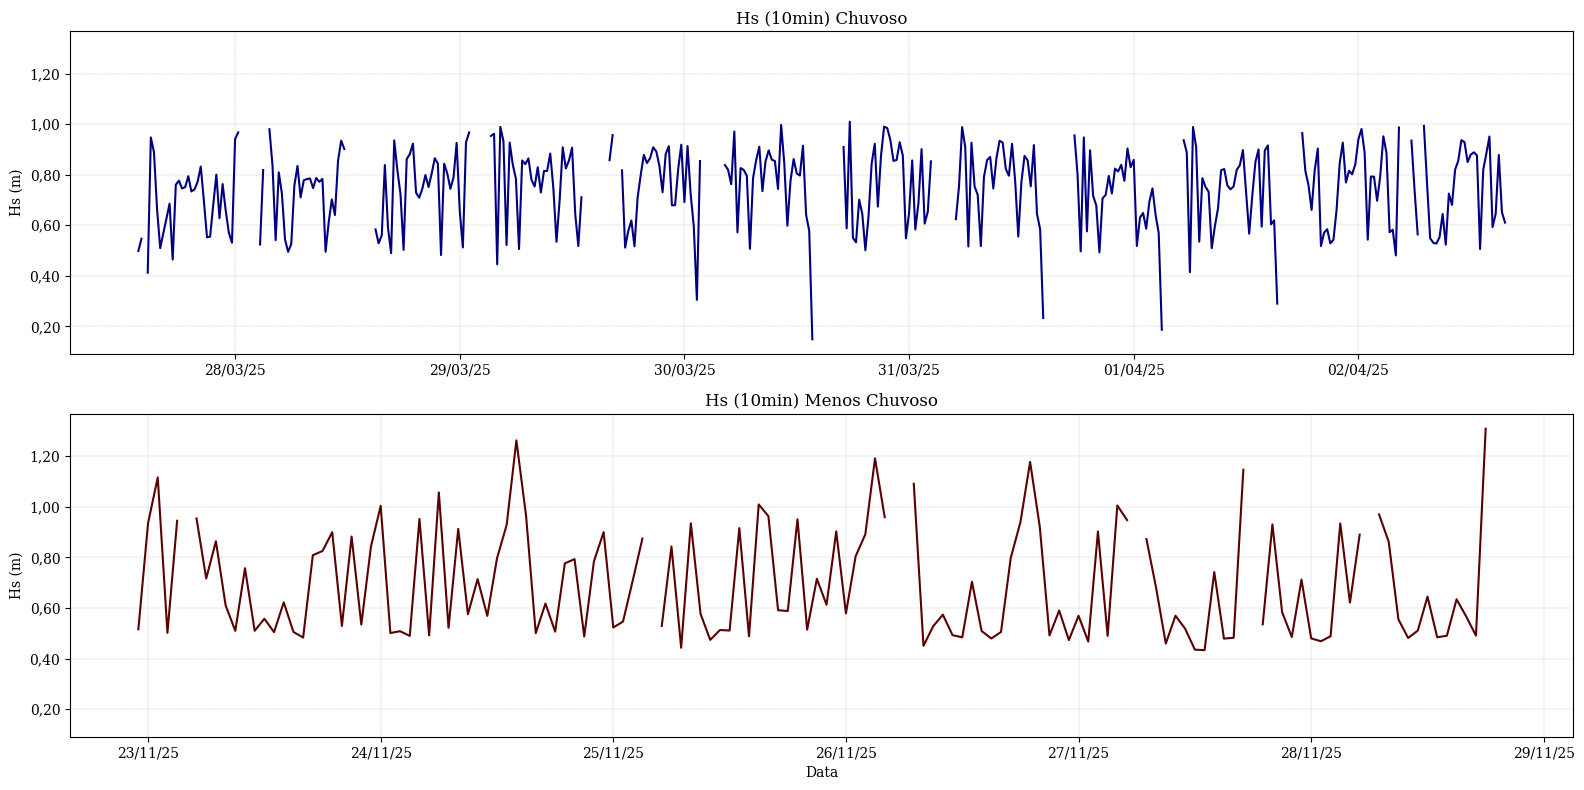

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso

ax[0].plot(
    df_Hs_10min_CHU_STRK['DataHora'],
    df_Hs_10min_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (10min) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# seco

ax[1].plot(
    df_Hs_10min_SEC_STRK['DataHora'],
    df_Hs_10min_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (10min) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

Esta célula gera um gráfico de dois painéis (um para 'Chuvoso' e outro para 'Menos Chuvoso') exibindo a altura significativa da onda (Hs) calculada a cada 10 minutos. Ambos os gráficos compartilham o mesmo eixo y (Hs em metros).

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente.
*   **Dados**: `df_Hs_10min_CHU_STRK` para o gráfico superior e `df_Hs_10min_SEC_STRK` para o gráfico inferior.
*   **Títulos**: Cada subplot tem um título descritivo indicando o período (Chuvoso/Menos Chuvoso) e o intervalo (10min).
*   **Rótulos dos Eixos**: O eixo Y é 'Hs (m)', e o eixo X inferior é 'Data'.
*   **Formatação**: Inclui uma grade, formatador de eixo y personalizado para vírgulas decimais e formatação de data para o eixo x (`%d/%m/%y`). `plt.tight_layout()` ajusta os parâmetros do subplot para um layout compacto.

### Hs 30 mim

In [ ]:
df_Hs_30min_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '30min'
    )
)

df_Hs_30min_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '30min'
    )
)


Estas células calculam a altura significativa da onda (Hs) para os períodos 'Chuvoso' e 'Seco', desta vez em intervalos de 30 minutos, usando a função `calc_hs_intervalo`. Os resultados são armazenados em `df_Hs_30min_CHU_STRK` e `df_Hs_30min_SEC_STRK`.

### Fig Hs 30min

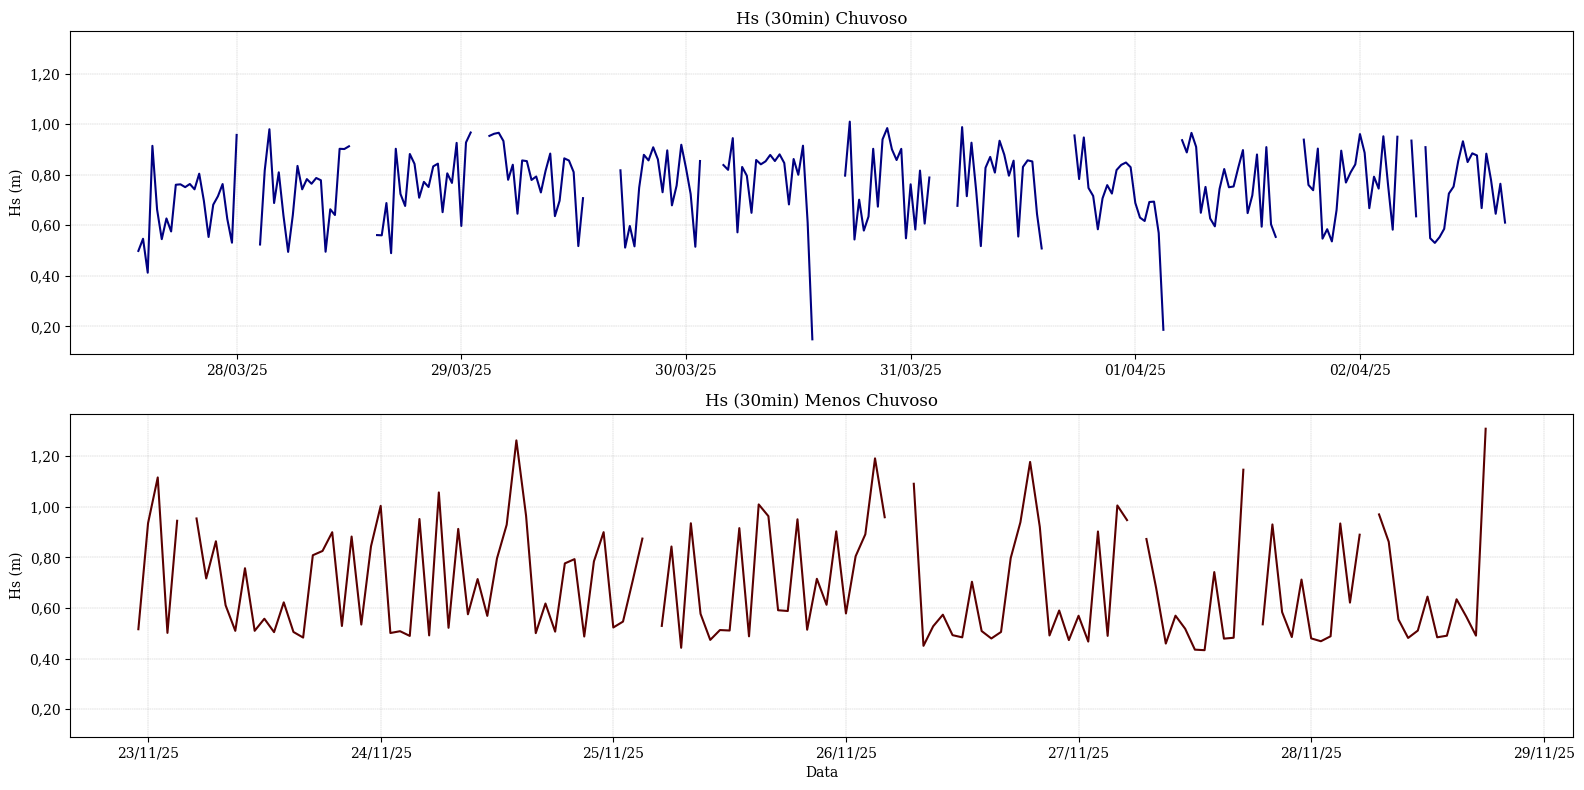

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# =========================================================
# CHUVOSO
# =========================================================

ax[0].plot(
    df_Hs_30min_CHU_STRK['DataHora'],
    df_Hs_30min_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (30min) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

# grid discreto

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

# vírgula eixo y

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# =========================================================
# MENOS CHUVOSO
# =========================================================

ax[1].plot(
    df_Hs_30min_SEC_STRK['DataHora'],
    df_Hs_30min_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (30min) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

# grid discreto

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

# vírgula eixo y

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# formato data

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

Esta célula gera um gráfico de dois painéis (um para 'Chuvoso' e outro para 'Menos Chuvoso') exibindo a altura significativa da onda (Hs) calculada a cada 30 minutos. Ambos os gráficos compartilham o mesmo eixo y (Hs em metros).

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente.
*   **Dados**: `df_Hs_30min_CHU_STRK` para o gráfico superior e `df_Hs_30min_SEC_STRK` para o gráfico inferior.
*   **Títulos**: Cada subplot tem um título descritivo indicando o período (Chuvoso/Menos Chuvoso) e o intervalo (30min).
*   **Rótulos dos Eixos**: O eixo Y é 'Hs (m)', e o eixo X inferior é 'Data'.
*   **Formatação**: Inclui uma grade sutil, formatador de eixo y personalizado para vírgulas decimais e formatação de data para o eixo x (`%d/%m/%y`). `plt.tight_layout()` ajusta os parâmetros do subplot para um layout compacto.

### Hs 1H

In [ ]:
df_Hs_1H_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '1H'
    )
)

df_Hs_1H_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '1H'
    )
)

/tmp/ipykernel_2458/2005773031.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(
/tmp/ipykernel_2458/2005773031.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


Estas células calculam a altura significativa da onda (Hs) para os períodos 'Chuvoso' e 'Seco', desta vez em intervalos de 1 hora, usando a função `calc_hs_intervalo`. Os resultados são armazenados em `df_Hs_1H_CHU_STRK` e `df_Hs_1H_SEC_STRK`.

### Fig Hs 1H

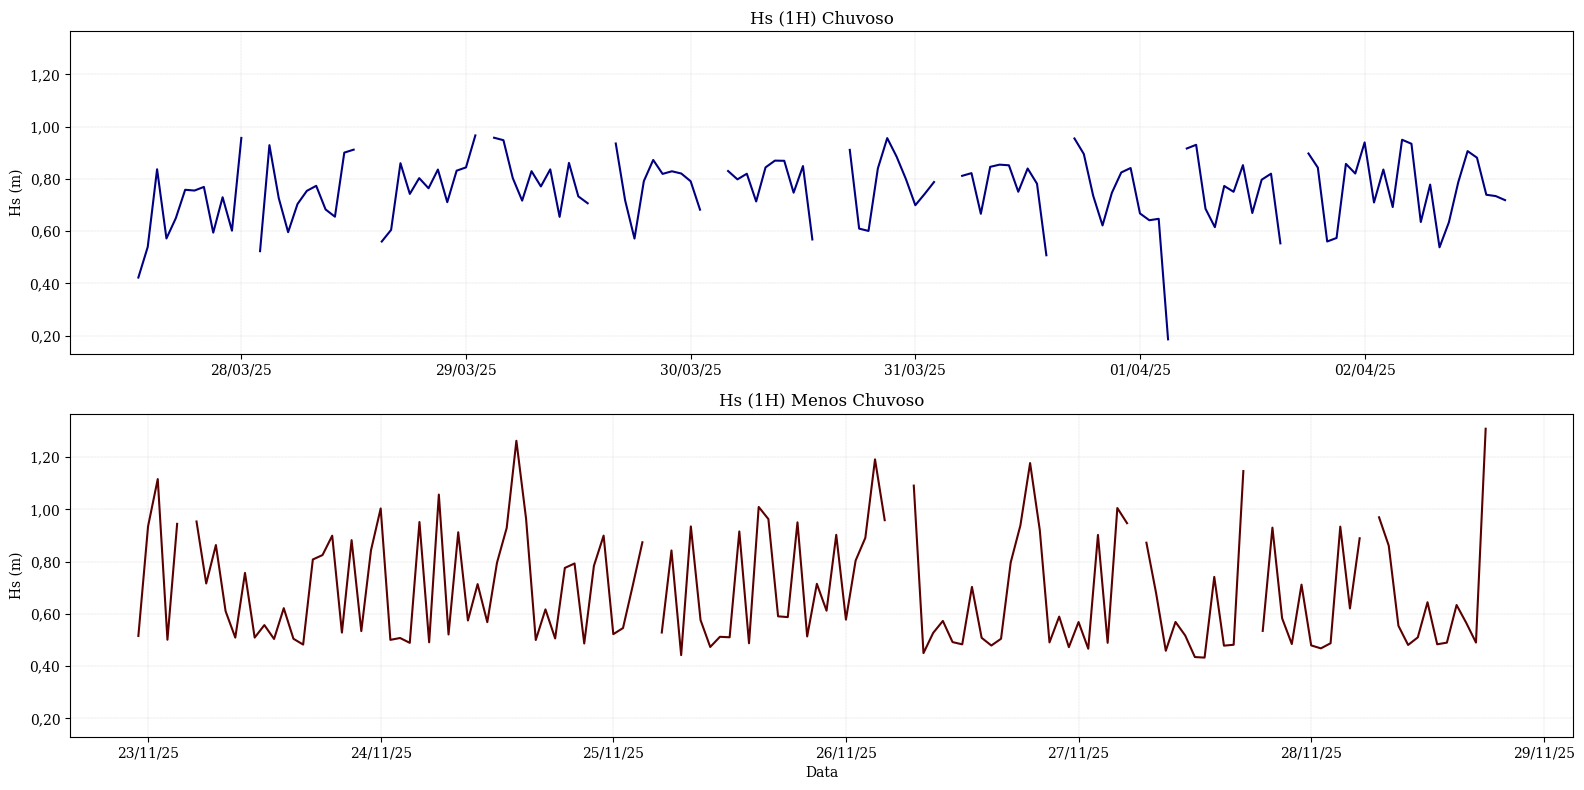

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso

ax[0].plot(
    df_Hs_1H_CHU_STRK['DataHora'],
    df_Hs_1H_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (1H) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# seco

ax[1].plot(
    df_Hs_1H_SEC_STRK['DataHora'],
    df_Hs_1H_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (1H) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

Esta célula gera um gráfico de dois painéis (um para 'Chuvoso' e outro para 'Menos Chuvoso') exibindo a altura significativa da onda (Hs) calculada a cada 1 hora. Ambos os gráficos compartilham o mesmo eixo y (Hs em metros).

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente.
*   **Dados**: `df_Hs_1H_CHU_STRK` para o gráfico superior e `df_Hs_1H_SEC_STRK` para o gráfico inferior.
*   **Títulos**: Cada subplot tem um título descritivo indicando o período (Chuvoso/Menos Chuvoso) e o intervalo (1H).
*   **Rótulos dos Eixos**: O eixo Y é 'Hs (m)', e o eixo X inferior é 'Data'.
*   **Formatação**: Inclui uma grade sutil, formatador de eixo y personalizado para vírgulas decimais e formatação de data para o eixo x (`%d/%m/%y`). `plt.tight_layout()` ajusta os parâmetros do subplot para um layout compacto.

### Hs 3H

In [ ]:
df_Hs_3H_CHU_STRK = (
    calc_hs_intervalo(
        df_strk_chu,
        '3H'
    )
)

df_Hs_3H_SEC_STRK = (
    calc_hs_intervalo(
        df_strk_sec,
        '3H'
    )
)

/tmp/ipykernel_2458/2005773031.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(
/tmp/ipykernel_2458/2005773031.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  grupos = df.resample(


Estas células calculam a altura significativa da onda (Hs) para os períodos 'Chuvoso' e 'Seco', desta vez em intervalos de 3 horas, usando a função `calc_hs_intervalo`. Os resultados são armazenados em `df_Hs_3H_CHU_STRK` e `df_Hs_3H_SEC_STRK`.

### Fig Hs 3H

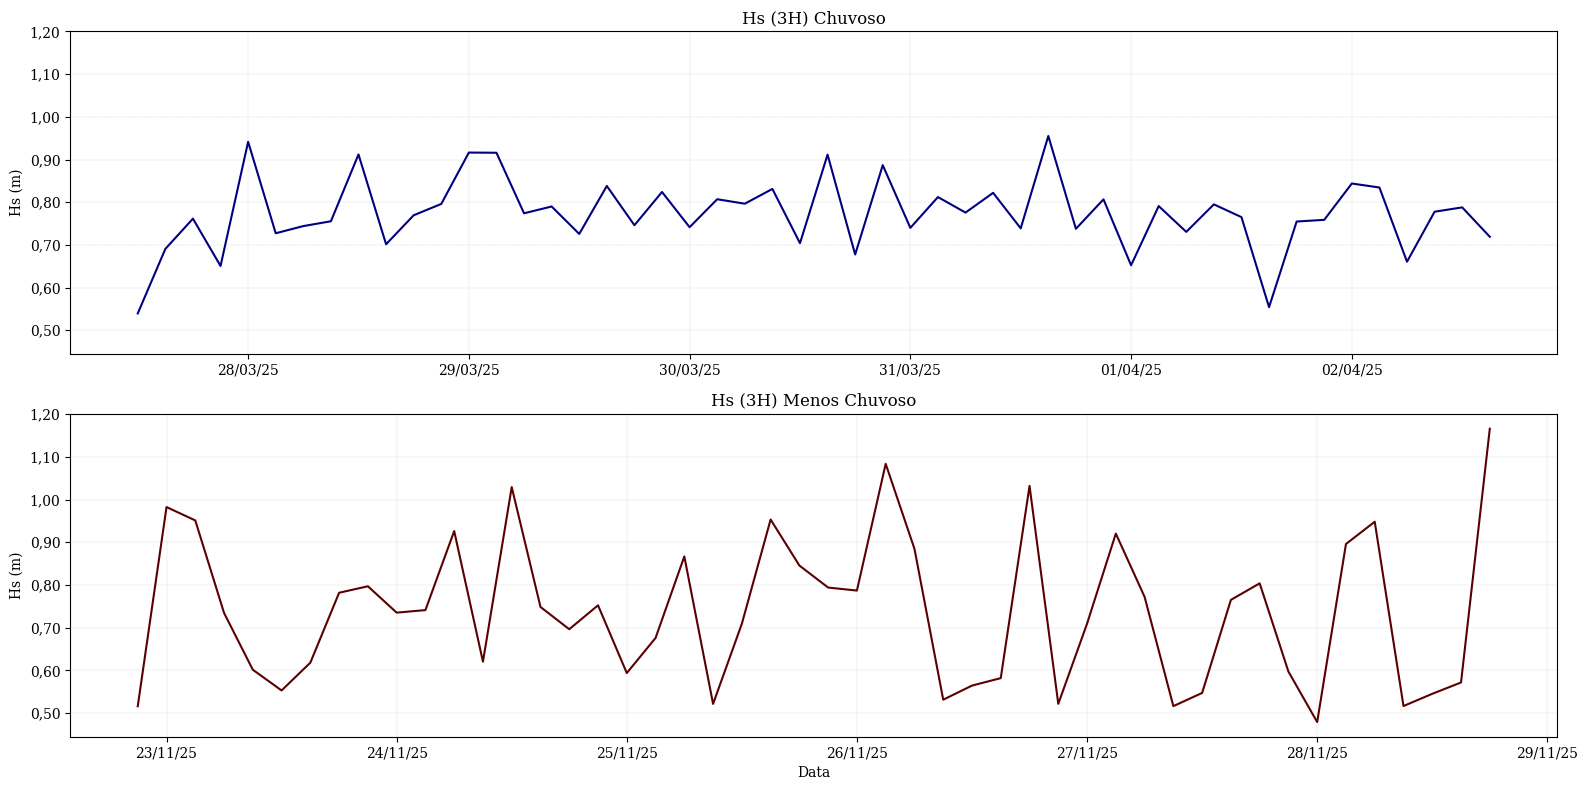

In [ ]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# chuvoso

ax[0].plot(
    df_Hs_3H_CHU_STRK['DataHora'],
    df_Hs_3H_CHU_STRK['Hs'],
    color='navy'
)

ax[0].set_title(
    'Hs (3H) Chuvoso'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

# seco

ax[1].plot(
    df_Hs_3H_SEC_STRK['DataHora'],
    df_Hs_3H_SEC_STRK['Hs'],
    color='#5A0000'
)

ax[1].set_title(
    'Hs (3H) Menos Chuvoso'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.2,
    alpha=0.9
)

ax[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(
        comma_formatter
    )
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter(
        '%d/%m/%y'
    )
)

plt.tight_layout()
plt.show()

Esta célula gera um gráfico de dois painéis (um para 'Chuvoso' e outro para 'Menos Chuvoso') exibindo a altura significativa da onda (Hs) calculada a cada 3 horas. Ambos os gráficos compartilham o mesmo eixo y (Hs em metros).

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente.
*   **Dados**: `df_Hs_3H_CHU_STRK` para o gráfico superior e `df_Hs_3H_SEC_STRK` para o gráfico inferior.
*   **Títulos**: Cada subplot tem um título descritivo indicando o período (Chuvoso/Menos Chuvoso) e o intervalo (3H).
*   **Rótulos dos Eixos**: O eixo Y é 'Hs (m)', e o eixo X inferior é 'Data'.
*   **Formatação**: Inclui uma grade sutil, formatador de eixo y personalizado para vírgulas decimais e formatação de data para o eixo x (`%d/%m/%y`). `plt.tight_layout()` ajusta os parâmetros do subplot para um layout compacto.

## Fig Comparativa

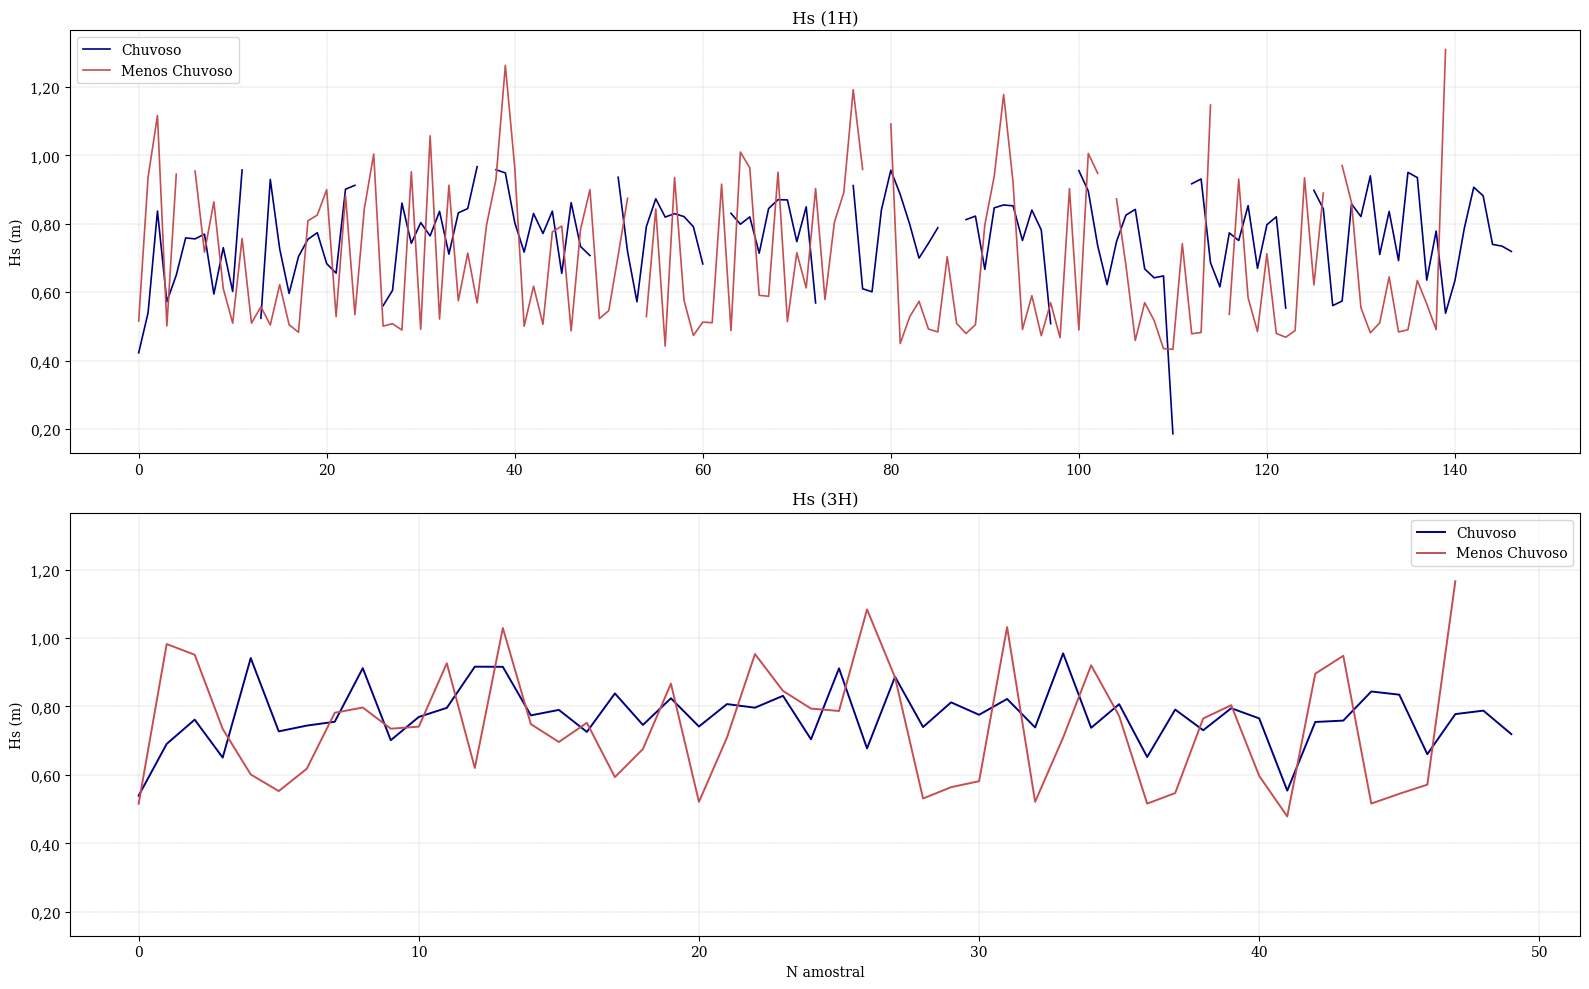

In [ ]:
# =========================================================
# FIGURA COMPARATIVA
# SOMENTE Hs 1H E 3H
# =========================================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,10),
    sharey=True
)

# =========================================================
# ÍNDICES
# =========================================================

x_1h_chu = np.arange(
    len(df_Hs_1H_CHU_STRK)
)

x_1h_sec = np.arange(
    len(df_Hs_1H_SEC_STRK)
)

x_3h_chu = np.arange(
    len(df_Hs_3H_CHU_STRK)
)

x_3h_sec = np.arange(
    len(df_Hs_3H_SEC_STRK)
)

# =========================================================
# COR MENOS CHUVOSO
# =========================================================

cor_sec = '#C44E52'



# =========================================================
# Hs 1H
# =========================================================

ax[0].plot(
    x_1h_chu,
    df_Hs_1H_CHU_STRK['Hs'],
    color='navy',
    linewidth=1.2,
    label='Chuvoso'
)

ax[0].plot(
    x_1h_sec,
    df_Hs_1H_SEC_STRK['Hs'],
    color=cor_sec,
    linewidth=1.2,
    label='Menos Chuvoso'
)

ax[0].set_title(
    'Hs (1H)'
)

ax[0].set_ylabel(
    'Hs (m)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[0].legend()

# =========================================================
# Hs 3H
# =========================================================

ax[1].plot(
    x_3h_chu,
    df_Hs_3H_CHU_STRK['Hs'],
    color='navy',
    linewidth=1.4,
    label='Chuvoso'
)

ax[1].plot(
    x_3h_sec,
    df_Hs_3H_SEC_STRK['Hs'],
    color=cor_sec,
    linewidth=1.4,
    label='Menos Chuvoso'
)

ax[1].set_title(
    'Hs (3H)'
)

ax[1].set_ylabel(
    'Hs (m)'
)

ax[1].set_xlabel(
    'N amostral'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.9
)

ax[1].legend()

# =========================================================
# FORMATAÇÃO
# =========================================================

for eixo in ax:

    eixo.yaxis.set_major_formatter(
        mticker.FuncFormatter(
            comma_formatter
        )
    )

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Ondas/Dados/Refinados/Hs_1H_3H.jpg', dpi=450, format='jpg')
plt.show()


Esta célula gera um gráfico comparativo com dois painéis, focando em Hs calculada para intervalos de 1 hora e 3 horas, para os períodos 'Chuvoso' e 'Menos Chuvoso'. Os gráficos mostram os valores de Hs em relação a um índice de amostra, em vez de datas reais, para comparação direta de tendências.

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente, compartilhando o eixo y.
*   **Dados**: Usa `df_Hs_1H_CHU_STRK`, `df_Hs_1H_SEC_STRK`, `df_Hs_3H_CHU_STRK` e `df_Hs_3H_SEC_STRK`.
*   **Índices**: `x_1h_chu`, `x_1h_sec`, `x_3h_chu`, `x_3h_sec` são criados como índices numéricos para plotagem.
*   **Cor**: Uma cor específica (`#C44E52`) é definida para o período 'Menos Chuvoso'.
*   **Gráfico Superior (Hs 1H)**: Exibe Hs (1H) para os períodos 'Chuvoso' e 'Menos Chuvoso' com uma legenda.
*   **Gráfico Inferior (Hs 3H)**: Exibe Hs (3H) para os períodos 'Chuvoso' e 'Menos Chuvoso' com uma legenda. O eixo x é rotulado 'N amostral' (número da amostra).
*   **Formatação**: Inclui títulos, rótulos do eixo y ('Hs (m)'), grades e formatador de eixo y personalizado para vírgulas decimais. `plt.tight_layout()` ajusta o layout, e `plt.savefig()` salva a figura como uma imagem JPEG.

## Séries de T

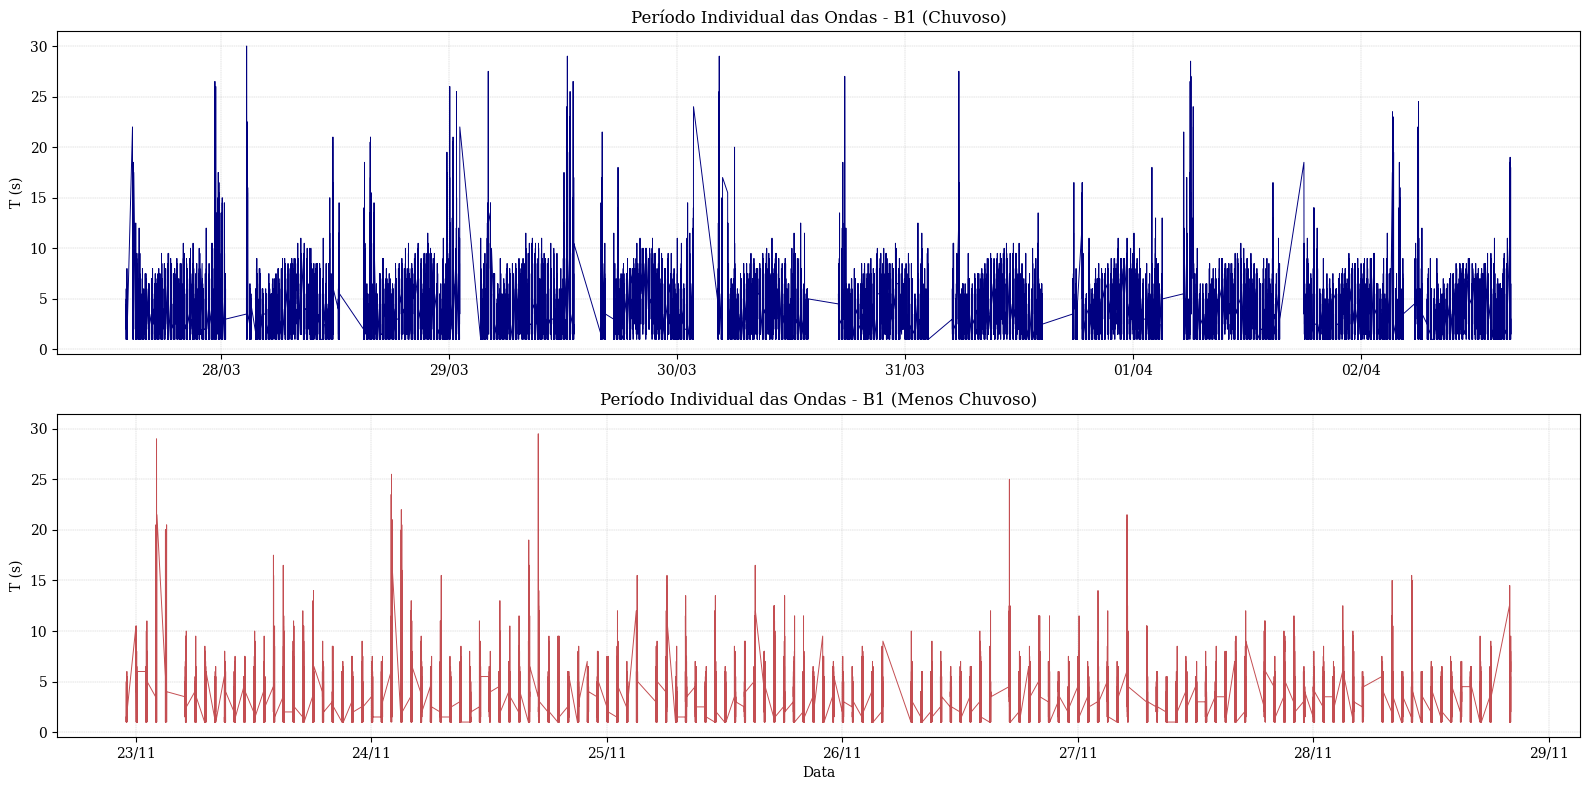

In [ ]:
# =========================================================
# PERÍODO DAS ONDAS AO LONGO DO TEMPO
# =========================================================

fig, ax = plt.subplots(
    2,
    1,
    figsize=(16,8),
    sharey=True
)

# =========================================================
# CHUVOSO
# =========================================================

ax[0].plot(
    df_ondas_CHU['DataHora'],
    df_ondas_CHU['B1_T'],
    color='navy',
    linewidth=0.7
)

ax[0].set_title(
    'Período Individual das Ondas - B1 (Chuvoso)'
)

ax[0].set_ylabel(
    'T (s)'
)

ax[0].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.8
)

# =========================================================
# MENOS CHUVOSO
# =========================================================

ax[1].plot(
    df_ondas_SEC['DataHora'],
    df_ondas_SEC['B1_T'],
    color='#C44E52',
    linewidth=0.7
)

ax[1].set_title(
    'Período Individual das Ondas - B1 (Menos Chuvoso)'
)

ax[1].set_ylabel(
    'T (s)'
)

ax[1].set_xlabel(
    'Data'
)

ax[1].grid(
    True,
    linestyle='--',
    linewidth=0.3,
    alpha=0.8
)

ax[0].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m')
)

ax[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d/%m')
)

plt.tight_layout()

plt.show()

Esta célula gera um gráfico de dois painéis visualizando os períodos de onda individuais (T) do Feixe 1 ao longo do tempo para os períodos 'Chuvoso' e 'Menos Chuvoso'.

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente, compartilhando o eixo y.
*   **Dados**: `df_ondas_CHU['B1_T']` para o gráfico superior e `df_ondas_SEC['B1_T']` para o gráfico inferior.
*   **Títulos**: Cada subplot tem um título indicando 'Período Individual das Ondas - B1' e o respectivo período (Chuvoso/Menos Chuvoso).
*   **Rótulos dos Eixos**: O eixo Y é 'T (s)', e o eixo X inferior é 'Data'.
*   **Formatação**: Inclui uma grade e formatação de data para o eixo x (`%d/%m`). `plt.tight_layout()` ajusta os parâmetros do subplot para um layout compacto.

### Histograma de T

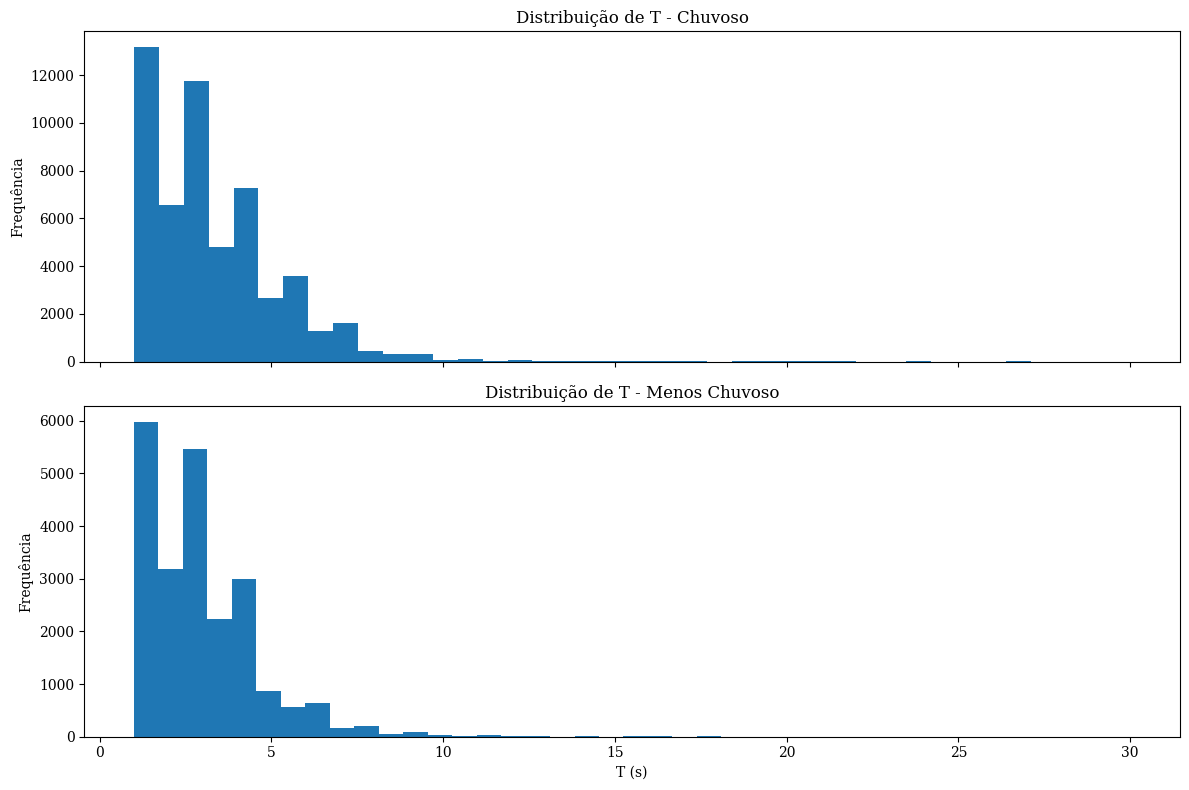

In [ ]:
# =========================================================
# HISTOGRAMA DOS PERÍODOS
# =========================================================

fig, ax = plt.subplots(
    2, # 2 linhas
    1, # 1 coluna
    figsize=(12,8),
    sharex=True
)

# chuvoso

ax[0].hist(
    df_ondas_CHU['B1_T'].dropna(),
    bins=40
)

ax[0].set_title(
    'Distribuição de T - Chuvoso'
)

ax[0].set_ylabel(
    'Frequência'
)

# seco

ax[1].hist(
    df_ondas_SEC['B1_T'].dropna(),
    bins=40
)

ax[1].set_title(
    'Distribuição de T - Menos Chuvoso'
)

ax[1].set_xlabel(
    'T (s)'
)

ax[1].set_ylabel(
    'Frequência'
)

plt.tight_layout()

plt.show()

Esta célula gera um gráfico de histograma de dois painéis mostrando a distribuição dos períodos de onda individuais (T) do Feixe 1 para os períodos 'Chuvoso' e 'Menos Chuvoso'.

**Detalhes do Gráfico:**
*   **Layout**: Dois subplots organizados verticalmente, compartilhando o eixo x.
*   **Dados**: `df_ondas_CHU['B1_T']` para o histograma superior e `df_ondas_SEC['B1_T']` para o histograma inferior.
*   **Bins**: Ambos os histogramas usam 40 bins para categorizar os períodos.
*   **Títulos**: Cada subplot tem um título indicando a 'Distribuição de T' e o respectivo período (Chuvoso/Menos Chuvoso).
*   **Rótulos dos Eixos**: O eixo Y é 'Frequência', e o eixo X inferior é 'T (s)'.
*   **Formatação**: `dropna()` é usado para excluir quaisquer valores ausentes do cálculo do histograma. `plt.tight_layout()` ajusta os parâmetros do subplot para um layout compacto.

### Descritiva de T

In [ ]:
print(df_ondas_CHU[['B1_T','B2_T','B3_T','B4_T']].describe())

print(df_ondas_SEC[['B1_T','B2_T','B3_T','B4_T']].describe())

               B1_T          B2_T          B3_T          B4_T
count  54231.000000  55403.000000  61337.000000  59831.000000
mean       3.298326      3.226811      2.886602      2.962051
std        2.071653      2.161983      2.065399      2.135949
min        1.000000      1.000000      1.000000      1.000000
25%        2.000000      1.500000      1.500000      1.500000
50%        3.000000      2.500000      2.500000      2.500000
75%        4.500000      4.000000      3.500000      3.500000
max       30.000000     29.500000     30.000000     30.000000
               B1_T          B2_T          B3_T          B4_T
count  22633.000000  20848.000000  20595.000000  22614.000000
mean       2.979057      3.170352      3.190119      2.985628
std        1.838290      2.274984      2.317175      1.825586
min        1.000000      1.000000      1.000000      1.000000
25%        1.500000      1.500000      1.500000      1.500000
50%        2.500000      2.500000      2.500000      2.500000
75%     

Estas células imprimem as estatísticas descritivas (contagem, média, desvio padrão, mínimo, máximo, quartis) para os períodos de onda (T) de todos os quatro feixes (`B1_T`, `B2_T`, `B3_T`, `B4_T`) para os dataframes 'Chuvoso' (`df_ondas_CHU`) e 'Menos Chuvoso' (`df_ondas_SEC`). Isso fornece um resumo da distribuição dos períodos de onda em cada conjunto de dados.

# 9.EXPORTAÇÃO

## Exportação p/ 'Refinados"

In [ ]:
pasta_saida = ('/content/drive/MyDrive/'
    'Ondas/Dados/Refinados/')

df_ondas_CHU.to_csv(pasta_saida + 'Ondas_CHU.csv',index=False)

df_ondas_SEC.to_csv(pasta_saida + 'Ondas_SEC.csv',index=False)

Estas células exportam os DataFrames `df_ondas_CHU` e `df_ondas_SEC` (contendo parâmetros de ondas individuais) para arquivos CSV nomeados `Ondas_CHU.csv` e `Ondas_SEC.csv` respectivamente, dentro da pasta de saída especificada. `index=False` impede a gravação do índice do DataFrame no CSV.

In [ ]:
# séries completas

Strk_CHU.to_csv(pasta_saida + 'Strk_CHU.csv',index=False)

Strk_SEC.to_csv( pasta_saida + 'Strk_SEC.csv',index=False)

# Hs 10 min

df_Hs_10min_CHU_STRK.to_csv(pasta_saida + 'Hs_10min_CHU.csv',index=False)

df_Hs_10min_SEC_STRK.to_csv(pasta_saida + 'Hs_10min_SEC.csv',index=False)

# Hs 30min

df_Hs_30min_CHU_STRK.to_csv(pasta_saida + 'Hs_30min_CHU.csv', index=False)

df_Hs_30min_SEC_STRK.to_csv( pasta_saida + 'Hs_30min_SEC.csv', index=False)


# Hs 1H

df_Hs_1H_CHU_STRK.to_csv(pasta_saida + 'Hs_1H_CHU.csv',index=False)

df_Hs_1H_SEC_STRK.to_csv(pasta_saida + 'Hs_1H_SEC.csv',index=False)

# Hs 3H

df_Hs_3H_CHU_STRK.to_csv(pasta_saida + 'Hs_3H_CHU.csv',index=False)

df_Hs_3H_SEC_STRK.to_csv(pasta_saida + 'Hs_3H_SEC.csv',index=False)

print('Todos os arquivos foram salvos.')

Todos os arquivos foram salvos.


Esta célula exporta vários DataFrames processados para arquivos CSV no diretório 'Refinados':
*   `Strk_CHU.csv` e `Strk_SEC.csv`: Os dataframes completos de surfacetrack processados.
*   `Hs_10min_CHU.csv` e `Hs_10min_SEC.csv`: Altura significativa da onda calculada a cada 10 minutos.
*   `Hs_30min_CHU.csv` e `Hs_30min_SEC.csv`: Altura significativa da onda calculada a cada 30 minutos.
*   `Hs_1H_CHU.csv` e `Hs_1H_SEC.csv`: Altura significativa da onda calculada a cada 1 hora.
*   `Hs_3H_CHU.csv` e `Hs_3H_SEC.csv`: Altura significativa da onda calculada a cada 3 horas.

Após todos os arquivos serem salvos, ele imprime uma mensagem de confirmação.

# 10.ESTATÍSTICAS FINAIS

## Descrição estatistica

In [ ]:
print('--- Descrição do DataFrame Strk_CHU ---')
display(Strk_CHU.describe(include='all'))

print('\n--- Descrição do DataFrame Strk_SEC ---')
display(Strk_SEC.describe(include='all'))

--- Descrição do DataFrame Strk_CHU ---


,DataHora,B1_h,B2_h,B3_h,B4_h
count,450561,4.491730e+05,4.490730e+05,4.477940e+05,4.492650e+05
mean,2025-03-30 14:34:16.336698880,2.900578e-05,1.690277e-05,3.783882e-05,3.435977e-05
min,2025-03-27 13:20:00,-1.051216e+00,-1.106762e+00,-1.246241e+00,-1.440199e+00
25%,2025-03-29 02:00:00,-9.161268e-02,-9.000431e-02,-1.115657e-01,-1.200314e-01
50%,2025-03-30 14:40:00,-1.110223e-16,-1.110223e-16,-1.110223e-16,-1.110223e-16
75%,2025-04-01 03:20:00,8.131744e-02,8.532965e-02,1.021243e-01,1.204347e-01
max,2025-04-02 16:00:00,9.404158e-01,9.796692e-01,1.214910e+00,1.129148e+00
std,NaN,1.722695e-01,1.901656e-01,2.213073e-01,2.242827e-01



--- Descrição do DataFrame Strk_SEC ---


,DataHora,B1_h,B2_h,B3_h,B4_h
count,145408,1.449350e+05,1.449520e+05,144716.000000,145124.000000
mean,2025-11-25 21:34:15.750000384,3.864003e-07,5.733525e-07,0.000033,-0.000016
min,2025-11-22 23:00:00,-1.056629e+00,-1.247886e+00,-1.134711,-1.049868
25%,2025-11-24 10:04:15.875000064,-1.305956e-01,-1.440337e-01,-0.144493,-0.127963
50%,2025-11-25 21:34:15.750000128,0.000000e+00,0.000000e+00,0.000000,0.000000
75%,2025-11-27 09:04:15.624999936,1.222137e-01,1.422652e-01,0.144398,0.121399
max,2025-11-28 20:08:31.500000,1.121744e+00,1.350198e+00,1.184141,1.059208
std,NaN,2.126969e-01,2.238916e-01,0.227112,0.211966


Estas células exibem uma descrição estatística abrangente dos DataFrames `Strk_CHU` e `Strk_SEC` usando `describe(include='all')`. Isso fornece estatísticas de resumo para todas as colunas, incluindo as não numéricas, o que pode ser útil para entender a distribuição geral dos dados e suas características.

## Quantidade de NaN

In [ ]:
# quantidade de NaN

print(df_Hs_1H_CHU_STRK['Hs'].isna().sum())

print( df_Hs_1H_SEC_STRK['Hs'].isna().sum())

print(df_Hs_3H_CHU_STRK['Hs'].isna().sum())

print( df_Hs_3H_SEC_STRK['Hs'].isna().sum())

18
8
0
0


Estas células contam e imprimem o número de valores `NaN` (ausentes) na coluna 'Hs' para os dataframes de altura significativa da onda calculados em intervalos de 1 hora e 3 horas, para os períodos 'Chuvoso' e 'Menos Chuvoso'. Isso ajuda a avaliar a completude dos dados após o processamento.

## Menor valor de Hs

In [ ]:
# =========================================================
# MENOR VALOR DE Hs EM CADA DF
# =========================================================

print(
    'Menor Hs 30min CHU:',
    df_Hs_30min_CHU_STRK['Hs'].min()
)

print(
    'Menor Hs 30min SEC:',
    df_Hs_30min_SEC_STRK['Hs'].min()
)

print(
    'Menor Hs 1H CHU:',
    df_Hs_1H_CHU_STRK['Hs'].min()
)

print(
    'Menor Hs 1H SEC:',
    df_Hs_1H_SEC_STRK['Hs'].min()
)

print(
    'Menor Hs 3H CHU:',
    df_Hs_3H_CHU_STRK['Hs'].min()
)

print(
    'Menor Hs 3H SEC:',
    df_Hs_3H_SEC_STRK['Hs'].min()
)

Menor Hs 30min CHU: 0.14861155586430308
Menor Hs 30min SEC: 0.43296372306550956
Menor Hs 1H CHU: 0.18626161116101833
Menor Hs 1H SEC: 0.43296372306550956
Menor Hs 3H CHU: 0.5394095836803544
Menor Hs 3H SEC: 0.47876804732802775


Estas células imprimem o valor mínimo da altura significativa da onda (Hs) encontrado nos dataframes de Hs com intervalos de 30 minutos, 1 hora e 3 horas, tanto para os períodos 'Chuvoso' quanto para os 'Menos Chuvoso'. Isso fornece uma visão das condições de onda mais baixas registradas durante esses intervalos.

## Maior valor de Hs

In [ ]:
print(
    'Maior Hs 30min CHU:',
    df_Hs_30min_CHU_STRK['Hs'].max()
)

print(
    'Maior Hs 30min SEC:',
    df_Hs_30min_SEC_STRK['Hs'].max()
)

print(
    'Maior Hs 1H CHU:',
    df_Hs_1H_CHU_STRK['Hs'].max()
)

print(
    'Maior Hs 1H SEC:',
    df_Hs_1H_SEC_STRK['Hs'].max()
)

print(
    'Maior Hs 3H CHU:',
    df_Hs_3H_CHU_STRK['Hs'].max()
)

print(
    'Maior Hs 3H SEC:',
    df_Hs_3H_SEC_STRK['Hs'].max()
)

Maior Hs 30min CHU: 1.0098431278085482
Maior Hs 30min SEC: 1.3090579200550858
Maior Hs 1H CHU: 0.9667909841460341
Maior Hs 1H SEC: 1.3090579200550858
Maior Hs 3H CHU: 0.9551479467260453
Maior Hs 3H SEC: 1.1659653082498962


Estas células imprimem o valor máximo da altura significativa da onda (Hs) encontrada nos dataframes de Hs com intervalos de 30 minutos, 1 hora e 3 horas, tanto para os períodos 'Chuvoso' quanto para os 'Menos Chuvoso'. Isso fornece uma visão das condições de onda mais altas registradas durante esses intervalos.